In [8]:
%load_ext autoreload
%autoreload 2

import logging
import re
from pathlib import Path
from typing import Any

import joblib
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from ppcluster import load_config, setup_logger

logger = setup_logger(logging.INFO, name="ppcx")

input_dir = Path("output")
output_dir = input_dir / "kinematic_sectors_time_series"

config = load_config()

if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

output_dir.mkdir(parents=True, exist_ok=True)

UNIT = "px"
UNIT_SCALE = 1.0  # 1 for px, or the m/px conversion factor

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
def find_result_folders(
    base_dir: Path, pattern: str = r".*_\d{4}-\d{2}-\d{2}$"
) -> list[Path]:
    """
    Find result folders matching `pattern` under `base_dir`.

    Args:
        base_dir: directory to scan for result folders
        pattern: regex to match folder names (default: CAMERA_YYYY-MM-DD)

    Returns:
        Sorted list of Path objects for folders that match the pattern.
    """
    folders = []
    date_pattern = re.compile(r"(\d{4}-\d{2}-\d{2})")

    for folder in base_dir.iterdir():
        if not folder.is_dir():
            continue
        if re.match(pattern, folder.name):
            # Extract date from folder name
            match = date_pattern.search(folder.name)
            if match:
                date_str = match.group(1)
                folders.append((date_str, folder))

    # Sort by date
    folders.sort(key=lambda x: x[0])

    # Return only folder paths
    folders = [folder for _, folder in folders]

    return folders


def load_sector_results(
    folder: Path, search_pattern: str | None = None
) -> dict[str, Any] | None:
    """
    Load a single date results bundle from `folder`.

    Args:
        folder: path to a results folder
        search_pattern: glob pattern to find the results bundle (default "*results.joblib")

    Returns:
        Dict with keys "date", "sectors", "stats", "pts_by_sector" on success, None on failure.
    """
    try:
        # Auto-detect base_name from folder if not provided
        if search_pattern is None:
            search_pattern = "*results.joblib"

        # Look for the bundle file
        bundle_files = list(folder.glob(search_pattern))
        if not bundle_files:
            raise FileNotFoundError(f"No bundle file found in {folder}")

        if len(bundle_files) > 1:
            logger.warning(
                f"Multiple bundle files found in {folder}, using the first one"
            )
        bundle_path = bundle_files[0]

        # Load main results bundle
        if not bundle_path.exists():
            raise FileNotFoundError(f"Bundle file not found: {bundle_path}")

        bundle = joblib.load(bundle_path)
        if not isinstance(bundle, dict):
            raise ValueError(f"Invalid bundle format in {bundle_path}")

        # Extract relevant data
        date = bundle.get("reference_date", None)
        sectors = bundle.get("sectors", None)
        sector_stats = bundle.get("sector_stats", None)
        pts_by_sector = bundle.get("pts_by_sector", None)

        return {
            "date": date,
            "sectors": sectors,
            "stats": sector_stats,
            "pts_by_sector": pts_by_sector,
        }

    except Exception as exc:
        logger.error(f"Failed to load results from {folder}: {exc}")
        return None


def collect_statistics(
    results_list: list[dict[str, Any] | None],
) -> tuple[pd.DatetimeIndex, dict[str, dict[str, list[float | int]]]]:
    """
    Collect and reorganize time series statistics per sector.

    Args:
        results_list: list of result dicts returned by `load_sector_results` (may contain None)

    Returns:
        dates_dt: DatetimeIndex of sorted dates
        sector_data: dict mapping sector -> dict of lists aligned with dates_dt
    """
    if not results_list:
        logger.warning("collect_statistics: empty results_list")
        return pd.DatetimeIndex([]), {}

    processed = []
    all_sectors = set()

    for idx, result in enumerate(results_list):
        if not result:
            logger.warning(f"Skipping empty result at index {idx}")
            continue

        date = result.get("date")
        stats = result.get("stats")

        try:
            date_ts = pd.to_datetime(date)
        except Exception:
            logger.error(
                f"Invalid or missing date in result at index {idx}: {date!r}; skipping"
            )
            continue

        if stats is None or not isinstance(stats, pd.DataFrame) or stats.empty:
            logger.warning(f"No stats for date {date_ts.date()}; recording empty entry")
            processed.append((date_ts, pd.DataFrame()))
            continue

        # normalize column name for sector
        if "sector" not in stats.columns and "label" in stats.columns:
            stats = stats.rename(columns={"label": "sector"})

        if "sector" not in stats.columns:
            logger.error(
                f"Stats for date {date_ts.date()} missing 'sector' column; skipping"
            )
            processed.append((date_ts, pd.DataFrame()))
            continue

        # ensure expected columns exist with sensible defaults
        for col, default in [
            ("v_mean", np.nan),
            ("v_std", np.nan),
            ("v_median", np.nan),
            ("v_mad", np.nan),
            ("n_points", 0),
            ("area_px2", 0),
        ]:
            if col not in stats.columns:
                stats[col] = default

        # aggregate duplicate sector rows (simple, clear rules)
        agg = stats.groupby("sector", as_index=False).agg(
            {
                "v_mean": "mean",
                "v_std": "mean",
                "v_median": "median",
                "v_mad": "median",
                "n_points": "sum",
                "area_px2": "sum",
            }
        )

        processed.append((date_ts, agg))
        all_sectors.update(agg["sector"].astype(str).tolist())

    if not processed:
        logger.error(
            "collect_statistics: no valid processed results; returning empty dataset"
        )
        return pd.DatetimeIndex([]), {}

    # sort by date and build index
    processed.sort(key=lambda x: x[0])
    dates_dt = pd.DatetimeIndex([d for d, _ in processed])

    # initialize storage with defaults aligned to dates
    sector_data = {}
    for sector in sorted(all_sectors):
        sector_data[sector] = {
            "v_mean": [np.nan] * len(dates_dt),
            "v_std": [np.nan] * len(dates_dt),
            "v_median": [np.nan] * len(dates_dt),
            "v_mad": [np.nan] * len(dates_dt),
            "n_points": [0] * len(dates_dt),
            "area_px2": [0] * len(dates_dt),
        }

    # fill values; if a sector appears only later, it was already initialized above
    for i, (_, df) in enumerate(processed):
        if df.empty:
            continue
        for _, row in df.iterrows():
            sector = str(row["sector"])
            if sector not in sector_data:
                # new sector found after initial pass: add with defaults for previous dates
                sector_data[sector] = {
                    "v_mean": [np.nan] * len(dates_dt),
                    "v_std": [np.nan] * len(dates_dt),
                    "v_median": [np.nan] * len(dates_dt),
                    "v_mad": [np.nan] * len(dates_dt),
                    "n_points": [0] * len(dates_dt),
                    "area_px2": [0] * len(dates_dt),
                }
            sector_data[sector]["v_mean"][i] = (
                float(row["v_mean"]) if pd.notna(row["v_mean"]) else np.nan
            )
            sector_data[sector]["v_std"][i] = (
                float(row["v_std"]) if pd.notna(row["v_std"]) else np.nan
            )
            sector_data[sector]["v_median"][i] = (
                float(row["v_median"]) if pd.notna(row["v_median"]) else np.nan
            )
            sector_data[sector]["v_mad"][i] = (
                float(row["v_mad"]) if pd.notna(row["v_mad"]) else np.nan
            )
            sector_data[sector]["n_points"][i] = (
                int(row["n_points"]) if pd.notna(row["n_points"]) else 0
            )
            sector_data[sector]["area_px2"][i] = (
                float(row["area_px2"]) if pd.notna(row["area_px2"]) else 0.0
            )

    if not sector_data:
        logger.warning("collect_statistics: processed results but no sectors found")

    return dates_dt, sector_data


In [10]:
dir_pattern = r".*_\d{4}-\d{2}-\d{2}$"
results_pattern = "*results.joblib"

# Find result folders
logger.info(f"Searching for result folders in {input_dir}...")
folders = find_result_folders(input_dir, pattern=dir_pattern)
logger.info(f"Found {len(folders)} result folders")

# Load results from all dates
logger.info("Loading results from all dates...")
results_list = []
for folder in folders:
    result = load_sector_results(folder, search_pattern=results_pattern)
    if result is not None:
        results_list.append(result)

dates_dt, sector_data = collect_statistics(results_list)
logger.info(f"Successfully loaded {len(dates_dt)} / {len(folders)} results")

2026-01-21 15:21:51 | [INFO    ] Searching for result folders in output...
2026-01-21 15:21:51 | [INFO    ] Found 152 result folders
2026-01-21 15:21:51 | [INFO    ] Loading results from all dates...
2026-01-21 15:21:51 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-08: No bundle file found in output/PPCX_Tele_2020-06-08
2026-01-21 15:21:51 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-09: No bundle file found in output/PPCX_Tele_2020-06-09
2026-01-21 15:21:51 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-10: No bundle file found in output/PPCX_Tele_2020-06-10
2026-01-21 15:21:51 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-12: No bundle file found in output/PPCX_Tele_2020-06-12
2026-01-21 15:21:51 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-06-13: No bundle file found in output/PPCX_Tele_2020-06-13
2026-01-21 15:21:52 | [ERROR   ] Failed to load results from output/PPCX_Tele_2020-09-20: 

2026-01-21 15:21:55 | [INFO    ] Saved velocity time series to output/kinematic_sectors_time_series/sectors_time_series.png


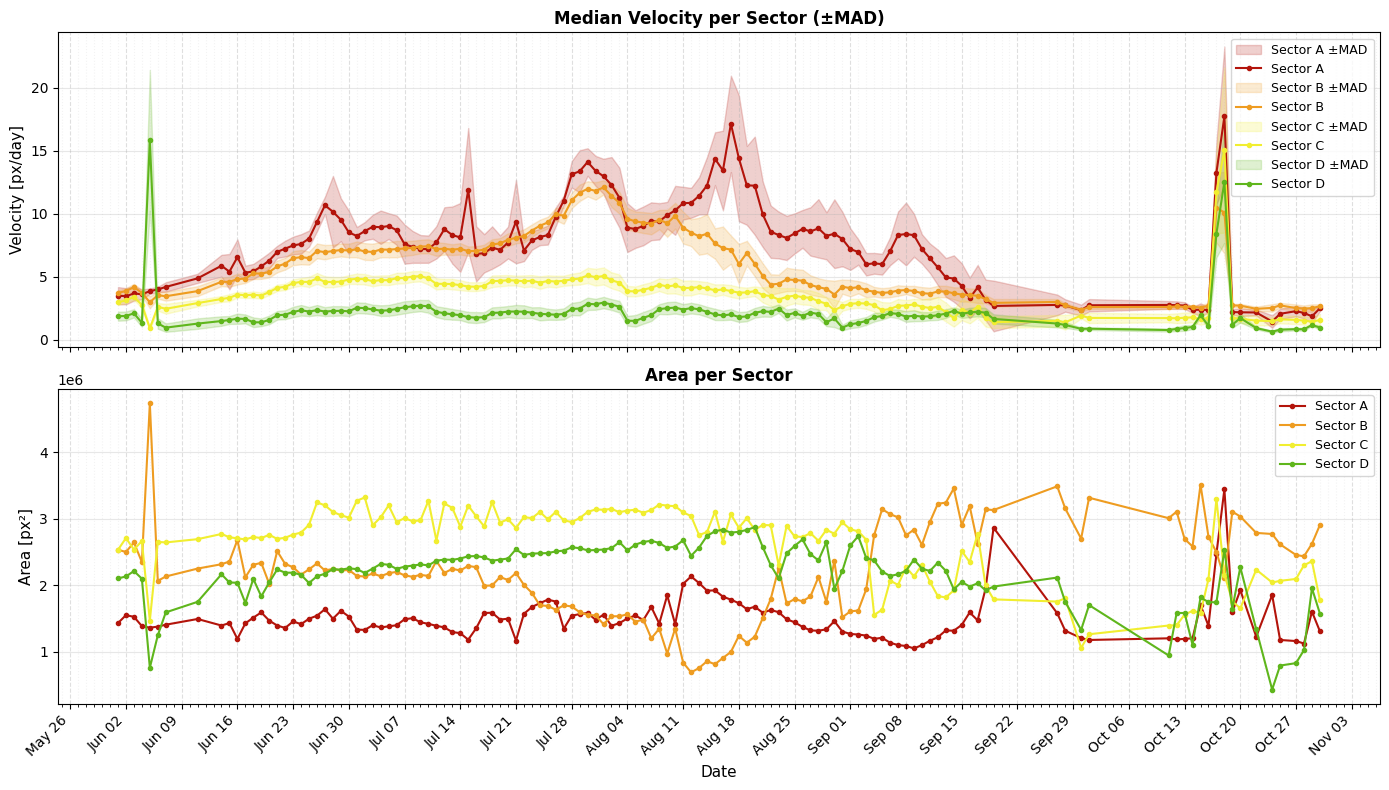

In [ ]:
# Create figure with time series of velocity and area of each sector (in different subplots)

output_path = output_dir / "sectors_time_series.png"


fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Get colormap
colors = config.postprocessing.sector_assignment.get("sector_colors", {})
if not colors:
    # Use default colormap if no colors are specified
    cmap = plt.get_cmap("tab10")
    colors = {
        sector: cmap(i % cmap.N) for i, sector in enumerate(sorted(sector_data.keys()))
    }

# Plot 1: Median velocity with MAD error bands
ax1 = axes[0]
for sector in sorted(sector_data.keys()):
    data = sector_data[sector]
    v_median = np.array(data["v_median"])
    v_mad = np.array(data["v_mad"])
    ax1.fill_between(
        dates_dt,
        v_median - v_mad,
        v_median + v_mad,
        color=colors[sector],
        alpha=0.2,
        label=f"Sector {sector} ±MAD",
    )
    ax1.plot(
        dates_dt,
        v_median,
        marker="o",
        markersize=3,
        linestyle="-",
        linewidth=1.5,
        label=f"Sector {sector}",
        color=colors[sector],
    )
ax1.set_ylabel(f"Velocity [{UNIT}/day]", fontsize=11)
ax1.set_title("Median Velocity per Sector (±MAD)", fontsize=12, weight="bold")
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Area of each sector over time
ax2 = axes[1]
for sector in sorted(sector_data.keys()):
    data = sector_data[sector]
    area_px2 = np.array(data["area_px2"])
    ax2.plot(
        dates_dt,
        area_px2,
        marker="o",
        markersize=3,
        linestyle="-",
        linewidth=1.5,
        label=f"Sector {sector}",
        color=colors[sector],
    )

ax2.set_xlabel("Date", fontsize=11)
ax2.set_ylabel(f"Area [{UNIT}²]", fontsize=11)
ax2.set_title("Area per Sector", fontsize=12, weight="bold")
ax2.legend(loc="best", fontsize=9)
ax2.grid(True, alpha=0.3)

# Set ticks for shared-x axes
major_locator = mdates.WeekdayLocator(interval=1)  # weekly ticks
# major_locator = mdates.AutoDateLocator(minticks=8, maxticks=20)  # auto ticks
major_formatter = mdates.DateFormatter("%b %d")  # or "%b %d" for compact labels
for ax in (ax1, ax2):
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_minor_locator(mdates.DayLocator())  # dayily minor ticks
    ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)
fig.autofmt_xdate(rotation=45, ha="right")  # rotate labels to avoid overlap

plt.tight_layout()

fig.savefig(output_path, dpi=300, bbox_inches="tight")
fig.savefig(output_path.with_suffix(".svg"), bbox_inches="tight")
logger.info(f"Saved velocity time series to {output_path}")

2026-01-21 15:29:00 | [INFO    ] Using fixed area bin size 1000000: bins [      0. 1000000. 2000000. 3000000. 4000000. 5000000.]


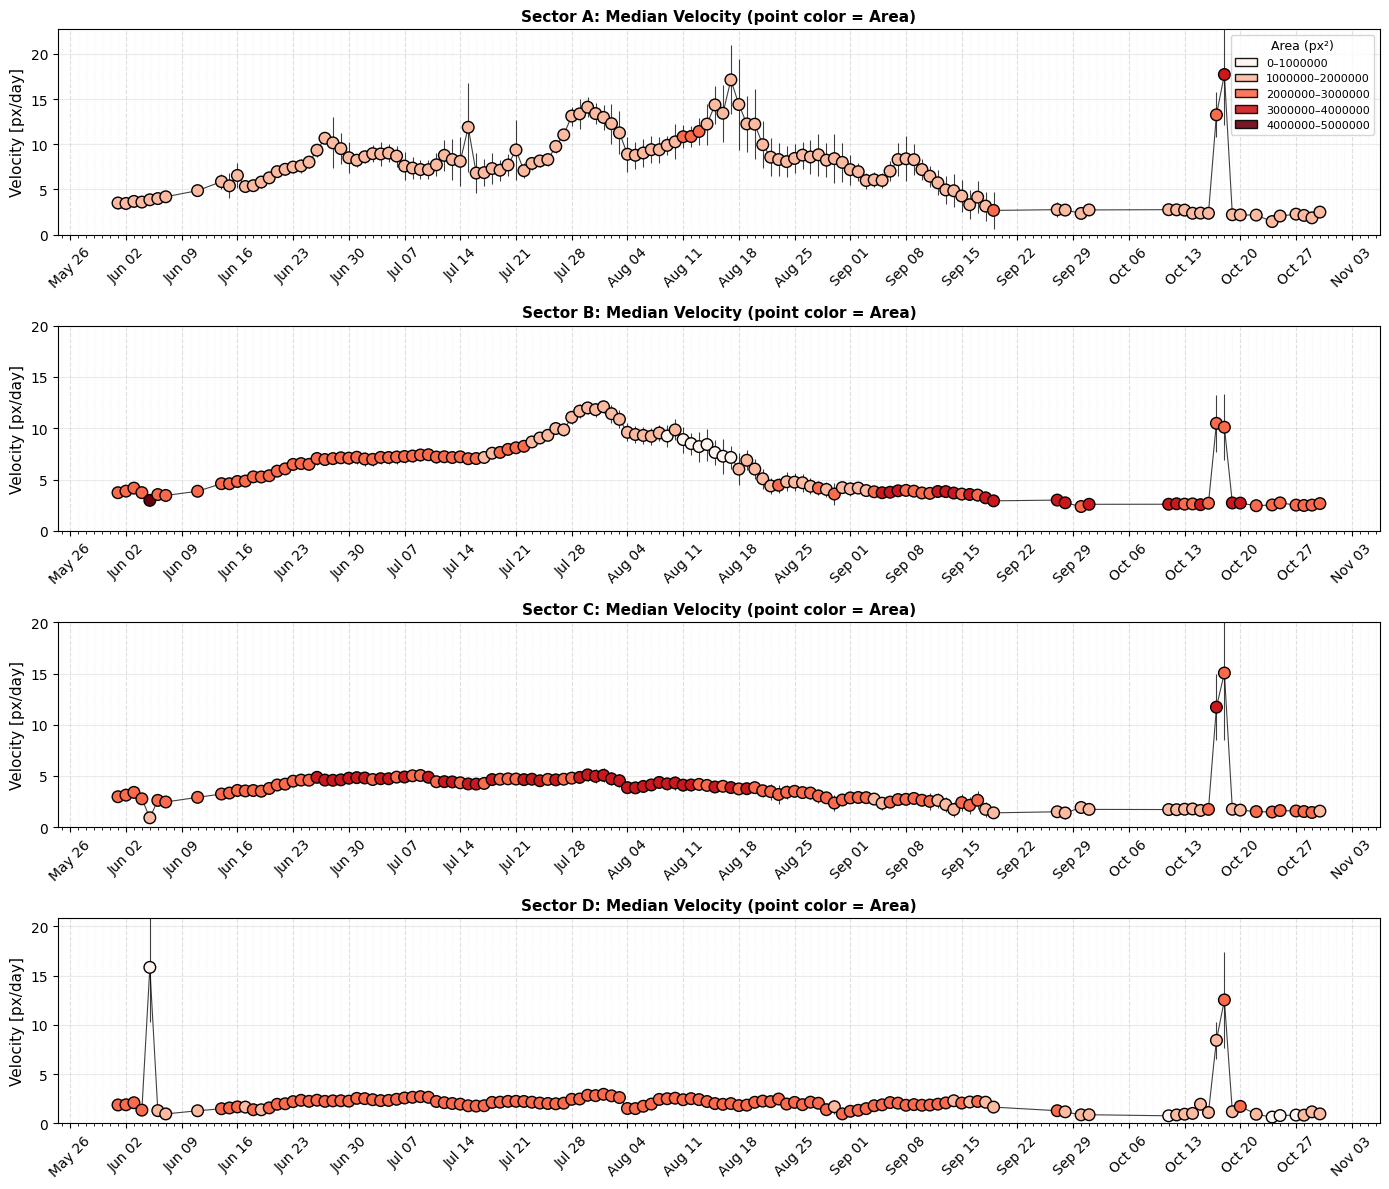

In [19]:
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

output_path = output_dir / "sectors_velocity_area_time_series.png"

# Combined plot velocity-area for each sector separately (one panel per sector)


# --- User-configurable binning options ---
# Option A: fixed integer bin size (px^2). Example: 500_000
area_bin_size: int | None = 1_000_000  # set to None to disable this option

# Option B: explicit bin edges list (overrides bin size if provided)
area_bin_edges: list[float] | None = None  # e.g. [0, 5e5, 1e6, 2e6]

# Fallback: number of evenly spaced bins if neither option is set
fallback_n_bins = 5

# compute global area range (ignore NaNs)
all_areas = (
    np.concatenate(
        [np.asarray(d["area_px2"], dtype=float) for d in sector_data.values()]
    )
    if sector_data
    else np.array([])
)
all_areas = all_areas[~np.isnan(all_areas)]
if all_areas.size == 0:
    min_a, max_a = 0.0, 1.0
else:
    min_a, max_a = float(np.nanmin(all_areas)), float(np.nanmax(all_areas))
    if np.isclose(min_a, max_a):
        max_a = min_a + 1.0

# Decide bins using a simple, clear approach:
if area_bin_edges is not None:
    bins = np.asarray(area_bin_edges, dtype=float)
    logger.info(f"Using user-provided area bin edges: {bins}")
elif area_bin_size:
    # round min/max to multiples of bin size to make clean integer bins
    start = np.floor(min_a / area_bin_size) * area_bin_size
    stop = np.ceil(max_a / area_bin_size) * area_bin_size
    if start == stop:
        stop = start + area_bin_size
    bins = np.arange(start, stop + area_bin_size, area_bin_size)
    logger.info(f"Using fixed area bin size {area_bin_size}: bins {bins}")
else:
    bins = np.linspace(min_a, max_a, fallback_n_bins + 1)
    logger.info(f"Using fallback linear bins (n={fallback_n_bins}): {bins}")

n_bins = max(1, len(bins) - 1)
cmap = plt.get_cmap("Reds", n_bins)
colors_list = [cmap(i) for i in range(n_bins)]

fig, axes = plt.subplots(
    min(4, len(sector_data)),
    1,
    figsize=(14, 3 * min(4, len(sector_data))),
    squeeze=False,
)
axes = axes.flatten()

# create legend patches for area bins (one-time)
area_patches = []
for i in range(n_bins):
    low, high = bins[i], bins[i + 1]
    label = f"{low:.0f}–{high:.0f}"
    area_patches.append(
        Patch(facecolor=colors_list[i], edgecolor="k", label=label, alpha=0.9)
    )

for ax, sector in zip(axes, sorted(sector_data.keys()), strict=False):
    data = sector_data[sector]
    v_median = np.array(data["v_median"], dtype=float)
    v_mad = np.array(data["v_mad"], dtype=float)
    area = np.array(data["area_px2"], dtype=float)

    # bin areas into discrete colors using numpy.digitize
    safe_area = np.nan_to_num(area, nan=bins[0])
    bin_idx = np.digitize(safe_area, bins) - 1  # index in 0..n_bins-1
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)
    colors_area = [colors_list[i] for i in bin_idx]

    ax.errorbar(
        dates_dt,
        v_median,
        yerr=v_mad,
        markersize=0,
        linestyle="-",
        linewidth=0.8,
        label=f"Sector {sector}",
        color="k",
        alpha=0.75,
    )
    ax.scatter(
        dates_dt,
        v_median,
        s=70,
        c=colors_area,
        edgecolors="k",
        zorder=3,
    )

    ax.set_ylabel(f"Velocity [{UNIT}/day]", fontsize=11)
    ax.set_title(
        f"Sector {sector}: Median Velocity (point color = Area)",
        fontsize=11,
        weight="bold",
    )
    ax.grid(axis="y", alpha=0.25)

    # same x ticks/formatting used elsewhere
    major_locator = mdates.WeekdayLocator(interval=1)
    major_formatter = mdates.DateFormatter("%b %d")
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_minor_locator(mdates.DayLocator())
    ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)
    
    ax.tick_params(axis="x", rotation=45)

    # Optional: consistent y-limits for better comparison
    ax.set_ylim([0, max(20, np.nanmax(v_median) + 5)])  # simple, avoids tiny ranges

# place area color legend in the first axis (clear and compact)
if axes.size > 0:
    axes[0].legend(
        handles=area_patches,
        title=f"Area ({UNIT}²)",
        loc="best",
        fontsize=8,
        title_fontsize=9,
    )

fig.tight_layout()

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    output_path.with_suffix(".svg"),
    bbox_inches="tight",
)

In [ ]:
# def create_sectors_evolution_figure(
#     results_list: list,
#     output_path: Path,
#     config: DictConfig,
#     max_dates: int = 12,
#     ncols: int = 4,
# ):
#     """
#     Create multi-panel figure showing sector evolution over time.

#     Args:
#         results_list: List of result dictionaries
#         output_path: Path to save the figure
#         config: DictConfig instance for loading images
#         max_dates: Maximum number of dates to show
#         ncols: Number of columns in the subplot grid
#     """
#     # Limit to max_dates
#     if len(results_list) > max_dates:
#         step = len(results_list) // max_dates
#         results_list = results_list[::step][:max_dates]

#     n_dates = len(results_list)
#     nrows = int(np.ceil(n_dates / ncols))

#     fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
#     if n_dates == 1:
#         axes = np.array([axes])
#     axes = axes.flatten()

#     # Get consistent colors for sectors
#     all_sectors = set()
#     for result in results_list:
#         if result and result["stats"] is not None:
#             all_sectors.update(result["stats"]["label"].values)

#     cmap = plt.get_cmap("tab10")
#     colors = {sector: cmap(i % cmap.N) for i, sector in enumerate(sorted(all_sectors))}

#     for idx, result in enumerate(results_list):
#         ax = axes[idx]

#         if result is None:
#             ax.axis("off")
#             continue

#         # Load image
#         try:
#             if config:
#                 img = None
#             else:
#                 img = None

#             if img is not None:
#                 ax.imshow(img, alpha=0.5, cmap="gray")
#         except Exception:
#             pass

#         # Draw sector polygons
#         sector_polygons = result["sector_polygons"]
#         legend_patches = {}

#         for sector in sorted(sector_polygons.keys()):
#             coords = sector_polygons[sector]
#             if coords is None:
#                 continue

#             color = colors.get(sector, "#888888")
#             draw_polygon(ax, coords, color, fill_alpha=0.2, zorder=1)
#             legend_patches[sector] = mpatches.Patch(
#                 color=color, label=f"{sector}", alpha=0.5
#             )

#         # Add legend only to first subplot
#         if idx == 0 and legend_patches:
#             ax.legend(
#                 handles=list(legend_patches.values()),
#                 labels=list(legend_patches.keys()),
#                 loc="upper right",
#                 fontsize=7,
#                 framealpha=0.9,
#             )

#         ax.set_aspect("equal")
#         ax.set_xticks([])
#         ax.set_yticks([])
#         ax.set_title(result["date"], fontsize=9)

#     # Hide unused subplots
#     for idx in range(n_dates, len(axes)):
#         axes[idx].axis("off")

#     plt.suptitle(
#         "Morpho-Kinematic Sectors Evolution", fontsize=14, weight="bold", y=0.995
#     )
#     plt.tight_layout()
#     fig.savefig(output_path, dpi=150, bbox_inches="tight")
#     plt.close(fig)
#     logger.info(f"Saved sectors evolution figure to {output_path}")
